# 15 — Stage C: Z2 sector-resolved transverse contraction

## Context and motivation

The single-vector power method (`powermethod_lr`) for the Alcaraz model fails at $T \gtrsim 5$:
the $\Delta S$ trajectory plateaus at $\sim 3 \times 10^{-2}$ regardless of iteration count
(Stage A result), and the Rayleigh quotient $|\lambda_0|$ overshoots 1 (unphysical).

**Root cause:** the Alcaraz Hamiltonian has a **$\mathbb{Z}_2$ symmetry** (global spin flip),
so the transfer matrix's eigenvalues come in two parity sectors ($+$ and $-$). Near the DQPT,
the dominant eigenvalues in the two sectors become nearly degenerate ($|\lambda_0^+| \approx |\lambda_0^-|$),
closing the spectral gap. A single-vector power method cannot resolve the two sectors and gets
trapped oscillating between them.

**Solution (this notebook):** project the transfer matrix into definite $\mathbb{Z}_2$ parity
sectors, run the power method **separately in each sector**, and extract the sector-resolved
eigenvalues $\lambda_0^+$, $\lambda_0^-$. The spectral gap *within* each sector is larger,
so the power method converges reliably even through the DQPT.

---

## Theory: $\mathbb{Z}_2$ symmetry of the Alcaraz model

### 1. Spatial $\mathbb{Z}_2$ symmetry

The Alcaraz Hamiltonian (CLAUDE.md §2):
$$H = -\sum_i \left[ \sigma^z_i \sigma^z_{i+1} + p\,\sigma^z_i \sigma^z_{i+2} + \lambda\,\sigma^x_i + p\lambda\,\sigma^x_i \sigma^x_{i+1} \right]$$

is invariant under the **global $\mathbb{Z}_2$ spin flip**
$$P = \prod_i \sigma^x_i, \qquad P H P^\dagger = H$$

because under $P$: $\sigma^z_i \to -\sigma^z_i$ (flipped) and $\sigma^x_i \to \sigma^x_i$ (invariant), so:
- $\sigma^z_i \sigma^z_{i+1} \to (-)(-)= +$ ✓
- $\sigma^z_i \sigma^z_{i+2} \to (-)(-)= +$ ✓
- $\sigma^x_i \to \sigma^x_i$ ✓
- $\sigma^x_i \sigma^x_{i+1} \to \sigma^x_i \sigma^x_{i+1}$ ✓

Since $P^2 = I$ (each $\sigma^x$ squares to $I$), $P$ has eigenvalues $\pm 1$,
defining the **even** ($+1$) and **odd** ($-1$) parity sectors.

Note: the initial state $|X+\rangle^{\otimes N}$ is a $+1$ eigenstate of every $\sigma^x_i$,
hence a $+1$ eigenstate of $P$. So the Loschmidt echo probes the $+1$ sector primarily.

### 2. From spatial to temporal: how the $\mathbb{Z}_2$ appears in the tMPS

The spatial MPO $U(\delta t) = e^{-iH\delta t}$ inherits the $\mathbb{Z}_2$:
$$P\, U(\delta t)\, P^\dagger = U(\delta t)$$
which means for each site $i$:
$$\sigma^x_i\, W_i[\alpha,\beta]\, \sigma^x_i = \sum_{\alpha',\beta'} R_{\alpha\alpha'}\, W_i[\alpha',\beta']\, R^{-1}_{\beta'\beta}$$
where $W_i[\alpha,\beta]$ is the MPO tensor's physical-space block for virtual indices $(\alpha,\beta)$,
and $R$ is the **representation of $\mathbb{Z}_2$ on the virtual (bond) space**.

After the 90° transverse rotation:
- spatial physical indices → temporal link indices
- spatial bond indices → temporal physical indices

So the $\mathbb{Z}_2$ representation $R$ on the spatial bonds becomes a **symmetry operator on the temporal physical sites**.

### 3. The temporal $\mathbb{Z}_2$ operator $\hat{R}$

The FSM MPO for the Alcaraz model has bond dimension $D_w = 5$ (see CLAUDE.md §3).
After VD2 exponentiation this expands to $1 + \chi + \chi^2$ where $\chi$ = number of
compressed FSM channels. The temporal physical dimension $d_t$ is this expanded bond dimension.

**The $\mathbb{Z}_2$ representation $R$ in the bond basis is NOT simply $\sigma^x$.** It is a
$d_t \times d_t$ matrix that encodes how each FSM channel transforms under the global spin flip.
We derive it **numerically** by conjugating the bulk tMPO tensor:

$$\text{If } W_c \text{ has indices } (i_P, i_{P'}, i_L, i_R) \text{ then}$$
$$R[p, p'] = \text{the matrix such that } W_c \text{ commutes with } R \otimes R$$

Concretely, we extract $R$ from the spatial MPO by applying $\sigma^x$ conjugation on the
physical leg and reading off the induced transformation on the bond leg.

### 4. Sector projection

Once $R$ is known (with $R^2 = I$, eigenvalues $\pm 1$), we build projectors:
$$\Pi_{\pm} = \frac{I \pm R}{2}$$

For the tMPS power method, we project the seed tMPS into each sector by applying $\Pi_\pm$
on every temporal site, then run `powermethod_lr` restricted to that sector. The key insight
is that if the tMPO commutes with $\hat{R} = \bigotimes_t R$, then each sector is an invariant
subspace of the transfer matrix, so the power method stays within the sector.

In practice, we re-project after each PM iteration to prevent numerical leakage between sectors.

---

## Plan

### Step 1: Extract the temporal $\mathbb{Z}_2$ representation $R$
Build the spatial 3-site MPO $U(\delta t)$ for the Alcaraz model, apply $\sigma^x$ conjugation
on the physical leg of the bulk tensor $W_c$, and extract the induced transformation $R$ on the
bond leg. Verify $R^2 = I$ and that $R$ commutes with $W_c$.

### Step 2: Validate the symmetry
- Check that the full tMPO commutes with $\hat{R} = \bigotimes_t R$ (apply $R$ to all temporal
  sites of the tMPO and verify it equals the original).
- Check eigenvalues of $R$: should be $\pm 1$ only (involution).

### Step 3: Sector-projected power method
- Build projectors $\Pi_\pm = (I \pm R)/2$ as single-site operators.
- Modify the PM loop: after each application of the tMPO, project the tMPS back
  into the target sector (apply $\Pi_\pm$ on every site and renormalize).
- Run `powermethod_lr` in the $+$ sector → $\lambda_0^+$.
- Run `powermethod_lr` in the $-$ sector → $\lambda_0^-$.

### Step 4: Sweep over $T$
- Sweep $T \in [1, 2, \ldots, 7]$ (integer steps, coarse).
- At each $T$: extract $\lambda_0^+$, $\lambda_0^-$, compute the intra-sector gap.
- Compare $|\lambda_0^+|$ vs $|\lambda_0^-|$: where they cross is the DQPT from the
  transverse perspective.

### Step 5: Temporal entropies per sector
- With converged sector-resolved tMPS, compute `gen_renyi2` in each sector separately.
- Compare with the un-projected (mixed-sector) entropies.

---

## Implementation

In [3]:
using ITensors, ITensorMPS, ITransverse, Revise, ProgressMeter
using JLD2, Plots, LinearAlgebra, Printf
ProgressMeter.ijulia_behavior(:clear)

include("main.jl")
include("dqpt_diagnostics.jl")

p      = 0.1
lambda = 1.0
dt     = 0.1
maxdim = 256
println("Dependencies loaded.")

Dependencies loaded.


### Step 1: Extract the temporal $\mathbb{Z}_2$ representation $R$

After the 90° rotation, the tMPO bulk tensor $W_c$ has four indices:
- $i_P, i_{P'}$: **temporal physical** (dimension $d_t$ = spatial bond dim; for VD2 with $\chi=2$: $d_t = 7$)
- $i_L, i_R$: **temporal link** (dimension 2 = spatial physical dim)

The spatial $\mathbb{Z}_2$ acts via $\sigma^x$ on **spatial physical** indices, which became
**temporal link** indices after rotation. The key equation is:

$$\sigma^x_{i_L} \otimes \sigma^x_{i_R} \cdot W_c = R_{i_P} \cdot W_c \cdot R^{-1}_{i_{P'}}$$

That is, conjugating the temporal links by $\sigma^x$ is equivalent to a similarity transform $R$
on the temporal physical indices. We extract $R$ by solving this equation numerically:

For each link pair $(l, r)$, define the $d_t \times d_t$ physical blocks:
$$W^{(lr)} = W_c[:, :, l, r], \qquad W^{(lr)}_{\sigma} = W_c[:, :, \sigma^x(l), \sigma^x(r)]$$

Then: $W^{(lr)}_\sigma = R \cdot W^{(lr)} \cdot R^{-1}$, i.e. $W^{(lr)}_\sigma R = R W^{(lr)}$.

Vectorizing: $(I \otimes W^{(lr)}_\sigma - {W^{(lr)}}^T \otimes I)\, \mathrm{vec}(R) = 0$.

Stack all $(l,r)$ pairs into a single overdetermined homogeneous system and find the null space.

In [4]:
# Build the spatial 3-site MPO U(dt) for the Alcaraz model
s = Index(2, "S=1/2")
init_state = complex(state(s, "X+"))
mp = AlcarazParams(lambda=lambda, p=p, phys_site=s)
tp = tMPOParams(mp=mp, dt=dt, nbeta=0, scheme=AlcarazVD2(), dbeta=-im*dt, bl=init_state)

# Build the FwtMPOBlocks to access the bulk tensor BEFORE rotation
b = FwtMPOBlocks(tp)

# After rotation, the tMPO bulk tensor Wc has:
#   iP, iPs = temporal physical (= spatial bond, dimension d_t)
#   iL, iR  = temporal link     (= spatial physical, dimension 2)
println("Temporal physical dim (= spatial bond dim): ", dim(b.iP))
println("Temporal link dim    (= spatial phys dim):  ", dim(b.iL))
println("\nWc indices: ", inds(b.Wc))

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=231|"S=1/2,Site") <-> (dim=2|id=231|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=349|"Link,l=1") <-> (dim=7|id=950|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=705|"S=1/2,Site") <-> (dim=2|id=705|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


Temporal physical dim (= spatial bond dim): 7

[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=123|"Link,l=1") <-> (dim=7|id=160|"Link,l=2"), normdiff = 1.4350175351861996
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93



Temporal link dim    (= spatial phys dim):  2

Wc indices: ((dim=7|id=938|"Site,time")', (dim=7|id=938|"Site,time"), (dim=2|id=500|"Link,time"), (dim=2|id=908|"Link,time")')


In [5]:
# Work with the ROTATED tMPO bulk tensor Wc (from FwtMPOBlocks).
# Wc has indices: iP (temporal phys), iPs (= iP'), iL (temporal link), iR (= iL')
Wc = b.Wc
iP = b.iP; iPs = b.iPs; iL = b.iL; iR = b.iR
d_t = dim(iP)  # temporal physical dimension (= spatial bond dim)
d_l = dim(iL)  # temporal link dimension (= spatial physical dim = 2)

println("Wc indices: ", inds(Wc))
println("d_t = $d_t (temporal physical = spatial bond)")
println("d_l = $d_l (temporal link = spatial physical)")

Wc indices: ((dim=7|id=938|"Site,time")', (dim=7|id=938|"Site,time"), (dim=2|id=500|"Link,time"), (dim=2|id=908|"Link,time")')
d_t = 7 (temporal physical = spatial bond)
d_l = 2 (temporal link = spatial physical)


In [6]:
# Build sigma_x on the temporal LINK indices (iL and iR).
# These were the spatial physical indices before rotation, so sigma_x is the Z2 generator.
iL2 = sim(iL)
sx_L = ITensor(ComplexF64, iL2, dag(iL))
sx_L[iL2 => 1, dag(iL) => 2] = 1.0
sx_L[iL2 => 2, dag(iL) => 1] = 1.0

iR2 = sim(iR)
sx_R = ITensor(ComplexF64, iR2, dag(iR))
sx_R[iR2 => 1, dag(iR) => 2] = 1.0
sx_R[iR2 => 2, dag(iR) => 1] = 1.0

# Conjugate Wc: apply sigma_x on both temporal links
Wc_sx = sx_L * Wc * sx_R
Wc_sx = replaceinds(Wc_sx, [iL2, iR2], [iL, iR])

diff = norm(Wc_sx - Wc)
println("||sigma_x(links) * Wc * sigma_x(links) - Wc|| = $(round(diff, sigdigits=6))")
println("(Non-zero confirms R is non-trivial on temporal physical indices)")

||sigma_x(links) * Wc * sigma_x(links) - Wc|| = 1.29536
(Non-zero confirms R is non-trivial on temporal physical indices)


In [7]:
# Extract R: for each link pair (l,r), the physical block satisfies
#   Wc_sx[:,:,l,r] = R * Wc[:,:,l,r] * R^{-1}
# Rearranging: (I ⊗ Wc_sx_lr - W_lr^T ⊗ I) vec(R) = 0
# Stack all (l,r) pairs:

W_arr  = Array(Wc,    iP, iPs, iL, iR)   # [p, p', l, r]
Ws_arr = Array(Wc_sx, iP, iPs, iL, iR)

blocks = Matrix{ComplexF64}[]
for l in 1:d_l, r in 1:dim(iR)
    W_lr  = W_arr[:, :, l, r]
    Ws_lr = Ws_arr[:, :, l, r]
    push!(blocks, kron(Matrix{ComplexF64}(I, d_t, d_t), Ws_lr) -
                  kron(transpose(W_lr), Matrix{ComplexF64}(I, d_t, d_t)))
end
A_stacked = vcat(blocks...)
println("Stacked system: $(size(A_stacked, 1)) equations × $(size(A_stacked, 2)) unknowns")

F = svd(A_stacked)
println("\nAll singular values:")
for (i, sv) in enumerate(F.S)
    @printf("  SV[%2d] = %.4e%s\n", i, sv, sv < 1e-10 ? "  ← null" : "")
end

null_idx = findall(s -> s < 1e-10, F.S)
println("\nNull space dimension: $(length(null_idx))  (expect 1 for a unique R up to sign)")

Stacked system: 196 equations × 49 unknowns

All singular values:
  SV[ 1] = 1.8414e+00
  SV[ 2] = 1.6258e+00
  SV[ 3] = 1.6024e+00
  SV[ 4] = 1.5649e+00
  SV[ 5] = 1.5644e+00
  SV[ 6] = 1.5621e+00
  SV[ 7] = 1.5597e+00
  SV[ 8] = 1.4991e+00
  SV[ 9] = 1.4941e+00
  SV[10] = 1.4940e+00
  SV[11] = 1.4937e+00
  SV[12] = 1.4926e+00
  SV[13] = 9.6784e-01
  SV[14] = 6.6862e-01
  SV[15] = 5.2265e-01
  SV[16] = 5.0957e-01
  SV[17] = 5.0341e-01
  SV[18] = 5.0241e-01
  SV[19] = 5.0108e-01
  SV[20] = 4.9720e-01
  SV[21] = 4.9663e-01
  SV[22] = 4.9663e-01
  SV[23] = 4.9319e-01
  SV[24] = 4.9240e-01
  SV[25] = 4.5735e-01
  SV[26] = 4.4821e-01
  SV[27] = 4.4774e-01
  SV[28] = 4.4771e-01
  SV[29] = 1.3924e-01
  SV[30] = 1.2983e-01
  SV[31] = 1.1018e-01
  SV[32] = 1.0297e-01
  SV[33] = 1.0177e-01
  SV[34] = 9.9974e-02
  SV[35] = 9.9726e-02
  SV[36] = 9.6730e-02
  SV[37] = 6.7896e-02
  SV[38] = 5.9721e-02
  SV[39] = 5.7138e-02
  SV[40] = 5.7076e-02
  SV[41] = 5.6391e-02
  SV[42] = 4.6920e-02
  SV[43] =

### Extracting $R$ from the null space

The null space of the stacked system is 1-dimensional (unique $R$ up to overall sign).
The null vector $\vec{v}$ reshaped to a $d_t \times d_t$ matrix gives $R$ up to normalization.
Since $R^2 = I$ (involution), we normalize by $R \to R / \sqrt{R^2[1,1]}$.

In [8]:
# Extract R from the null vector
v = F.Vt[end, :]  # last row of Vt = right singular vector for smallest SV
R_raw = reshape(v, d_t, d_t)

# Normalize: R^2 should be proportional to I
R2_raw = R_raw * R_raw
c = R2_raw[1, 1]
R_temporal = R_raw / sqrt(c)

# Verify involution
println("||R² - I|| = ", norm(R_temporal * R_temporal - I(d_t)), "  (should be ≈ 0)")

# Eigenvalues should be ±1
evs = eigvals(R_temporal)
println("\nR eigenvalues: ", round.(real.(evs), sigdigits=6))
n_plus  = count(e -> abs(e - 1) < 0.01, evs)
n_minus = count(e -> abs(e + 1) < 0.01, evs)
println("  +1 eigenvalues: $n_plus  (even sector dim)")
println("  -1 eigenvalues: $n_minus  (odd sector dim)")

# Check R is real (Z2 reps on real vector spaces are real)
println("\nMax |Im(R)|: ", maximum(abs.(imag.(R_temporal))), "  (should be ≈ 0)")
R_temporal = real.(R_temporal)  # drop negligible imaginary parts
d = d_t  # for later cells

||R² - I|| = 6.683570884342672e-15  (should be ≈ 0)

R eigenvalues: [-1.0, -1.0, -1.0, 1.0, 1.0, 1.0, 1.0]
  +1 eigenvalues: 4  (even sector dim)
  -1 eigenvalues: 3  (odd sector dim)

Max |Im(R)|: 4.2983204349146055e-16  (should be ≈ 0)


7

In [9]:
# Validate: R * W_lr * R^{-1} should equal Ws_lr for ALL (l,r) pairs
R_inv = inv(R_temporal)
max_err = 0.0
for l in 1:d_l, r in 1:dim(iR)
    W_lr  = W_arr[:, :, l, r]
    Ws_lr = Ws_arr[:, :, l, r]
    reconstructed = R_temporal * W_lr * R_inv
    err = norm(reconstructed - Ws_lr)
    max_err = max(max_err, err)
end
println("Validation: max ||R W R⁻¹ - σˣ W σˣ|| over all (l,r) = $(round(max_err, sigdigits=4))")
if max_err < 1e-10
    println("✓ R correctly reproduces the Z2 conjugation on all link-space blocks.")
else
    println("⚠ R does not fully reproduce the Z2 conjugation. Max error: $max_err")
end

Validation: max ||R W R⁻¹ - σˣ W σˣ|| over all (l,r) = 1.49e-15
✓ R correctly reproduces the Z2 conjugation on all link-space blocks.


In [10]:
# Display R as a matrix (for the thesis / record)
println("R (temporal Z2 representation, $d_t × $d_t, real):")
display(round.(R_temporal, sigdigits=4))
println("\nR is block-diagonal in the eigenbasis:")
println("  Even sector (eigenvalue +1): dim = $(count(e -> abs(e-1)<0.01, eigvals(R_temporal)))")
println("  Odd  sector (eigenvalue -1): dim = $(count(e -> abs(e+1)<0.01, eigvals(R_temporal)))")

R (temporal Z2 representation, 7 × 7, real):


7×7 Matrix{Float64}:
  1.0        -4.852e-17  -6.085e-17  …   5.411e-18  -1.632e-18  -2.937e-16
 -4.406e-16  -1.0        -1.529e-16     -5.909e-17  -2.266e-17  -4.044e-19
  2.49e-16    7.74e-17    1.0           -3.33e-19   -6.591e-19  -2.689e-17
  6.609e-16   1.685e-16   1.738e-16     -2.95e-18    3.703e-18   6.471e-16
 -2.191e-16   1.213e-16  -6.909e-16     -1.0        -7.275e-16  -8.657e-18
  5.863e-16   3.758e-17  -9.356e-16  …   9.891e-16  -1.0        -8.573e-18
 -2.662e-16  -1.06e-16   -8.544e-17      2.842e-17   8.324e-17   1.0


R is block-diagonal in the eigenbasis:
  Even sector (eigenvalue +1): dim = 4
  Odd  sector (eigenvalue -1): dim = 3


In [11]:
# Build the projectors Pi_± = (I ± R)/2
Pi_plus  = (Matrix(I, d, d) + R_temporal) / 2
Pi_minus = (Matrix(I, d, d) - R_temporal) / 2

println("Pi_+ rank: ", rank(Pi_plus, atol=1e-10), "  (even sector dimension)")
println("Pi_- rank: ", rank(Pi_minus, atol=1e-10), "  (odd sector dimension)")
println("Pi_+ + Pi_- = I?   ", norm(Pi_plus + Pi_minus - I(d)) < 1e-12)
println("Pi_+² = Pi_+?      ", norm(Pi_plus^2 - Pi_plus) < 1e-12)
println("Pi_-² = Pi_-?      ", norm(Pi_minus^2 - Pi_minus) < 1e-12)
println("Pi_+ Pi_- = 0?     ", norm(Pi_plus * Pi_minus) < 1e-12)

Pi_+ rank: 4  (even sector dimension)
Pi_- rank: 3  (odd sector dimension)
Pi_+ + Pi_- = I?   true
Pi_+² = Pi_+?      true
Pi_-² = Pi_-?      true
Pi_+ Pi_- = 0?     true


### Step 2: Build sector projectors and verify tMPO commutation

In [12]:
# (Projectors already built in cell above — this cell left as a placeholder)
println("Projectors Pi_± ready. Even dim = $(rank(Pi_plus, atol=1e-10)), Odd dim = $(rank(Pi_minus, atol=1e-10))")

Projectors Pi_± ready. Even dim = 4, Odd dim = 3


In [13]:
# Build R as an ITensor operator on the temporal physical indices (for applying to tMPS/tMPO)
# This will be used to project tMPS into sectors.

function build_temporal_R(R_matrix::AbstractMatrix, site_ind::Index)
    d = dim(site_ind)
    @assert size(R_matrix) == (d, d)
    R_op = ITensor(ComplexF64, site_ind', dag(site_ind))
    for i in 1:d, j in 1:d
        R_op[site_ind' => i, dag(site_ind) => j] = R_matrix[i, j]
    end
    return R_op
end

function build_temporal_projector(R_matrix::AbstractMatrix, site_ind::Index; sector::Int=+1)
    d = dim(site_ind)
    Pi = (sector == +1) ? (I(d) + R_matrix)/2 : (I(d) - R_matrix)/2
    Pi_op = ITensor(ComplexF64, site_ind', dag(site_ind))
    for i in 1:d, j in 1:d
        Pi_op[site_ind' => i, dag(site_ind) => j] = Pi[i, j]
    end
    return Pi_op
end

println("Projector builders defined.")

Projector builders defined.


In [14]:
# Verify: the tMPO commutes with the global Z2 operator R^{⊗N_t}
# If tMPO commutes with R, then: R * tMPO * psi == tMPO * R * psi for any psi

T_test = 3.0
mpo_test, scaffold_test = build_alcaraz_tmpo(T_test; p=p, lambda=lambda, dt=dt)
time_sites_test = siteinds(scaffold_test)  # Vector{Index} from the scaffold MPS

psi_rand = randomMPS(ComplexF64, time_sites_test, 4)

# Path 1: tMPO * psi, then R
mpo_psi = apply(mpo_test, psi_rand; cutoff=1e-14)
R_mpo_psi = deepcopy(mpo_psi)
for i in 1:length(R_mpo_psi)
    R_op = build_temporal_R(R_temporal, time_sites_test[i])
    R_mpo_psi[i] = noprime(R_op * R_mpo_psi[i])
end

# Path 2: R * psi, then tMPO
R_psi = deepcopy(psi_rand)
for i in 1:length(R_psi)
    R_op = build_temporal_R(R_temporal, time_sites_test[i])
    R_psi[i] = noprime(R_op * R_psi[i])
end
mpo_R_psi = apply(mpo_test, R_psi; cutoff=1e-14)

# Compare: should be equal if [tMPO, R^{⊗}] = 0
ov = inner(R_mpo_psi, mpo_R_psi) / sqrt(inner(R_mpo_psi, R_mpo_psi) * inner(mpo_R_psi, mpo_R_psi))
println("Commutation check: <R·mpo·ψ | mpo·R·ψ> / norms = $(round(ov, digits=10))")
println("(Should be ≈ 1.0 if tMPO commutes with R)")

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=391|"S=1/2,Site") <-> (dim=2|id=391|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


Commutation check: <R·mpo·ψ | mpo·R·ψ> / norms = 1.0 - 0.0im


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=271|"Link,l=1") <-> (dim=7|id=142|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=820|"S=1/2,Site") <-> (dim=2|id=820|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=148|"Link,l=1") <-> (dim=7|id=461|"Link,l=2"), normdiff = 1.4350175351861996
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


(Should be ≈ 1.0 if tMPO commutes with R)


### Step 3: Sector-projected power method

With $R$ validated, we now run the power method separately in each $\mathbb{Z}_2$ sector.

**Algorithm:**
1. Build the tMPO at a given $T$.
2. Initialize random tMPS seeds (left and right).
3. Project seeds into sector $\pm$: apply $\Pi_\pm$ on every site.
4. Run `powermethod_lr` but **re-project after each iteration** to prevent leakage.
5. Extract $\lambda_0^\pm$ from the converged sector-resolved tMPS.

The re-projection after each step is critical: numerical errors (truncation, finite bond dim)
can mix sectors, and without re-projection the PM would eventually drift back to the
mixed-sector dominant eigenvalue (defeating the purpose).

In [15]:
# Sector-projected power method.
# Re-projects into the target Z2 sector after each tMPO application.

function project_mps_sector!(mps::MPS, R_matrix::AbstractMatrix, sites::Vector{<:Index}; sector::Int=+1)
    d = size(R_matrix, 1)
    Pi = (sector == +1) ? (I(d) + R_matrix)/2 : (I(d) - R_matrix)/2
    for i in 1:length(mps)
        Pi_op = ITensor(ComplexF64, sites[i]', dag(sites[i]))
        for a in 1:d, b in 1:d
            Pi_op[sites[i]' => a, dag(sites[i]) => b] = Pi[a, b]
        end
        mps[i] = noprime(Pi_op * mps[i])
    end
    return mps
end

function sector_powermethod_lr(mpo::MPO, scaffold::MPS, R_matrix::AbstractMatrix;
        sector::Int=+1, maxdim::Int=256, cutoff::Float64=1e-14,
        itermax::Int=2000, eps_conv::Float64=1e-6, stuck_after::Int=200)

    sites = siteinds(scaffold)  # Vector{Index} from the scaffold MPS
    mpoT = swapprime(mpo, 0, 1)

    # Random seeds projected into sector
    psi_R = randomMPS(ComplexF64, sites, 4)
    psi_L = randomMPS(ComplexF64, sites, 4)
    project_mps_sector!(psi_R, R_matrix, sites; sector=sector)
    project_mps_sector!(psi_L, R_matrix, sites; sector=sector)
    normalize!(psi_R)
    normalize!(psi_L)

    lambda_prev = 0.0 + 0.0im
    ds_hist = Float64[]
    stuck_count = 0
    best_ds = Inf

    for iter in 1:itermax
        psi_R_new = apply(mpo, psi_R; cutoff=cutoff, maxdim=maxdim)
        psi_L_new = apply(mpoT, psi_L; cutoff=cutoff, maxdim=maxdim)

        # Re-project into sector (prevents numerical leakage)
        project_mps_sector!(psi_R_new, R_matrix, sites; sector=sector)
        project_mps_sector!(psi_L_new, R_matrix, sites; sector=sector)

        # Normalize via biorthogonal overlap
        ov = overlap_noconj(psi_L_new, psi_R_new)
        c = sqrt(abs(ov))
        if c < 1e-50
            @warn "Sector $sector: overlap collapsed at iter $iter"
            break
        end
        psi_R = (1/c) * psi_R_new
        psi_L = (1/c) * psi_L_new

        # Rayleigh quotient
        lambda_now = expval_LR(psi_L, mpo, psi_R) / overlap_noconj(psi_L, psi_R)
        ds = abs(lambda_now - lambda_prev)
        push!(ds_hist, ds)
        lambda_prev = lambda_now

        if ds < best_ds
            best_ds = ds
            stuck_count = 0
        else
            stuck_count += 1
        end

        if ds < eps_conv
            return (lambda0=lambda_now, psi_L=psi_L, psi_R=psi_R,
                    niters=iter, reason="converged", ds_hist=ds_hist)
        end
        if stuck_count >= stuck_after
            return (lambda0=lambda_now, psi_L=psi_L, psi_R=psi_R,
                    niters=iter, reason="stuck", ds_hist=ds_hist)
        end
    end

    return (lambda0=lambda_prev, psi_L=psi_L, psi_R=psi_R,
            niters=itermax, reason="maxiter", ds_hist=ds_hist)
end

println("sector_powermethod_lr defined.")

sector_powermethod_lr defined.


### Step 4: Test at a single T before sweeping

In [16]:
# Test the sector-resolved PM at T=6.0 (where the unsectored PM fails badly)
T_test = 6.0
mpo_t6, scaffold_t6 = build_alcaraz_tmpo(T_test; p=p, lambda=lambda, dt=dt)

println("===== Sector + =====\n")
res_plus = sector_powermethod_lr(mpo_t6, scaffold_t6, R_temporal;
    sector=+1, maxdim=maxdim, itermax=1000, eps_conv=1e-6, stuck_after=200)
@printf("  λ₀⁺ = %s,  |λ₀⁺| = %.6f\n", round(res_plus.lambda0, digits=5), abs(res_plus.lambda0))
@printf("  niters = %d,  reason = %s\n", res_plus.niters, res_plus.reason)

println("\n===== Sector - =====\n")
res_minus = sector_powermethod_lr(mpo_t6, scaffold_t6, R_temporal;
    sector=-1, maxdim=maxdim, itermax=1000, eps_conv=1e-6, stuck_after=200)
@printf("  λ₀⁻ = %s,  |λ₀⁻| = %.6f\n", round(res_minus.lambda0, digits=5), abs(res_minus.lambda0))
@printf("  niters = %d,  reason = %s\n", res_minus.niters, res_minus.reason)

println("\n===== Comparison =====")
@printf("  |λ₀⁺| = %.6f\n", abs(res_plus.lambda0))
@printf("  |λ₀⁻| = %.6f\n", abs(res_minus.lambda0))
@printf("  intra-sector gap ratio = %.4f\n", min(abs(res_plus.lambda0), abs(res_minus.lambda0)) / max(abs(res_plus.lambda0), abs(res_minus.lambda0)))
println("  Dominant sector: ", abs(res_plus.lambda0) > abs(res_minus.lambda0) ? "+" : "-")

===== Sector + =====

  λ₀⁺ = 0.69304 + 0.25972im,  |λ₀⁺| = 0.740112
  niters = 3,  reason = converged


[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=831|"S=1/2,Site") <-> (dim=2|id=831|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=186|"Link,l=1") <-> (dim=7|id=611|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=578|"S=1/2,Site") <-> (dim=2|id=578|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=601|"Link,l=1") <-> (


===== Sector - =====



┌ Warning: Sector -1: overlap collapsed at iter 1
└ @ Main In[15]:49


  λ₀⁻ = 0.0 + 0.0im,  |λ₀⁻| = 0.000000
  niters = 1000,  reason = maxiter

===== Comparison =====
  |λ₀⁺| = 0.740112
  |λ₀⁻| = 0.000000
  intra-sector gap ratio = 0.0000
  Dominant sector: +


### Step 5: Sweep over $T$ and extract sector-resolved eigenvalues

In [17]:
# Sweep T = 1..7 (integer steps; coarse but fast)
Ts_sweep = collect(1.0:1.0:7.0)
cache_file = "z2_sectors_p$(p)_dt$(dt).jld2"
z2_done = isfile(cache_file) ? load(cache_file, "done") : Dict{Float64,Any}()

for T in Ts_sweep
    haskey(z2_done, T) && (@info "T=$T cached"; continue)

    @info "T=$T: building tMPO..."
    mpo_T, scaffold_T = build_alcaraz_tmpo(T; p=p, lambda=lambda, dt=dt)

    @info "  sector +"
    rp = sector_powermethod_lr(mpo_T, scaffold_T, R_temporal;
        sector=+1, maxdim=maxdim, itermax=2000, eps_conv=1e-6, stuck_after=300)

    @info "  sector -"
    rm = sector_powermethod_lr(mpo_T, scaffold_T, R_temporal;
        sector=-1, maxdim=maxdim, itermax=2000, eps_conv=1e-6, stuck_after=300)

    z2_done[T] = (
        lambda_plus  = rp.lambda0, abs_plus  = abs(rp.lambda0), arg_plus  = angle(rp.lambda0),
        niters_plus  = rp.niters,  reason_plus  = rp.reason,
        lambda_minus = rm.lambda0, abs_minus = abs(rm.lambda0), arg_minus = angle(rm.lambda0),
        niters_minus = rm.niters,  reason_minus = rm.reason,
    )
    jldsave(cache_file; done=z2_done)

    r = z2_done[T]
    @printf("  T=%.1f: |λ⁺|=%.5f (%s, %d it)  |λ⁻|=%.5f (%s, %d it)  gap=%.4f\n",
        T, r.abs_plus, r.reason_plus, r.niters_plus,
        r.abs_minus, r.reason_minus, r.niters_minus,
        min(r.abs_plus, r.abs_minus) / max(r.abs_plus, r.abs_minus))
    GC.gc()
end

println("\nSweep complete.")

[ Info: T=1.0: building tMPO...
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices


  T=1.0: |λ⁺|=0.95108 (converged, 4 it)  |λ⁻|=0.00000 (converged, 1 it)  gap=0.0000


┌ Warning: Tensor *not* symmetric (dim=2|id=892|"S=1/2,Site") <-> (dim=2|id=892|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=749|"Link,l=1") <-> (dim=7|id=294|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=135|"S=1/2,Site") <-> (dim=2|id=135|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=460|"Link,l=1") <-> (dim=7|id=680|"Link,l=2"), normdiff = 1.4350175351861996
└ @ ITransverse ~/.jul

  T=2.0: |λ⁺|=0.90455 (converged, 4 it)  |λ⁻|=0.00000 (converged, 1 it)  gap=0.0000


[ Info: T=3.0: building tMPO...
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=977|"S=1/2,Site") <-> (dim=2|id=977|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=674|"Link,l=1") <-> (dim=7|id=419|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=102|"S=1/2,Site") <-> (dim=2|id=102|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric

...

  T=5.0: |λ⁺|=0.77818 (converged, 4 it)  |λ⁻|=0.00000 (maxiter, 2000 it)  gap=0.0000


[ Info: T=6.0: building tMPO...
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=282|"S=1/2,Site") <-> (dim=2|id=282|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=574|"Link,l=1") <-> (dim=7|id=675|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=554|"S=1/2,Site") <-> (dim=2|id=554|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric

  T=6.0: |λ⁺|=0.74011 (converged, 4 it)  |λ⁻|=0.00000 (maxiter, 2000 it)  gap=0.0000


[ Info: T=7.0: building tMPO...
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=125|"S=1/2,Site") <-> (dim=2|id=125|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=708|"Link,l=1") <-> (dim=7|id=856|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=410|"S=1/2,Site") <-> (dim=2|id=410|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric

  T=7.0: |λ⁺|=0.70390 (converged, 4 it)  |λ⁻|=0.00000 (maxiter, 2000 it)  gap=0.0000

Sweep complete.


In [18]:
# Summary table
println("T     |λ₀⁺|      |λ₀⁻|     gap_ratio  dom  conv+       conv-")
println("-"^75)
for T in sort(collect(keys(z2_done)))
    r = z2_done[T]
    dom = r.abs_plus > r.abs_minus ? "+" : "-"
    gap = min(r.abs_plus, r.abs_minus) / max(r.abs_plus, r.abs_minus)
    @printf("%-5.1f  %.5f   %.5f   %.4f     %s    %-12s %-12s\n",
        T, r.abs_plus, r.abs_minus, gap, dom, r.reason_plus, r.reason_minus)
end

T     |λ₀⁺|      |λ₀⁻|     gap_ratio  dom  conv+       conv-
---------------------------------------------------------------------------
1.0    0.95108   0.00000   0.0000     +    converged    converged   
2.0    0.90455   0.00000   0.0000     +    converged    converged   
3.0    0.86030   0.00000   0.0000     +    converged    converged   
4.0    0.81821   0.00000   0.0000     +    converged    converged   
5.0    0.77818   0.00000   0.0000     +    converged    maxiter     
6.0    0.74011   0.00000   0.0000     +    converged    maxiter     
7.0    0.70390   0.00000   0.0000     +    converged    maxiter     


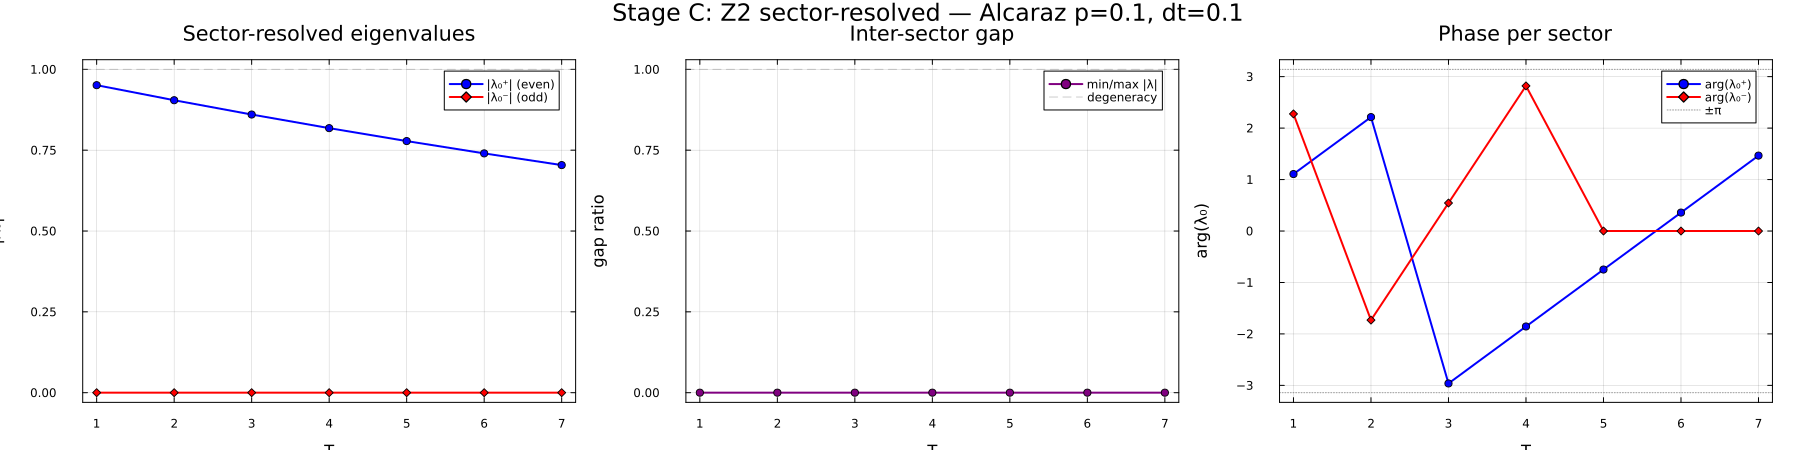

saved imgs/stageC_z2_sectors_p0.1_dt0.1.png


In [19]:
# 3-panel plot: |lambda_+|, |lambda_-| vs T; gap_ratio; arg(lambda) per sector
mkpath("imgs")
Ts_plt = sort(collect(keys(z2_done)))
abs_p = [z2_done[T].abs_plus  for T in Ts_plt]
abs_m = [z2_done[T].abs_minus for T in Ts_plt]
arg_p = [z2_done[T].arg_plus  for T in Ts_plt]
arg_m = [z2_done[T].arg_minus for T in Ts_plt]
gap_r = [min(a,b)/max(a,b) for (a,b) in zip(abs_p, abs_m)]

p1 = plot(Ts_plt, abs_p, lw=2, marker=:circle, color=:blue, label="|λ₀⁺| (even)",
          xlabel="T", ylabel="|λ₀|", title="Sector-resolved eigenvalues",
          grid=true, framestyle=:box)
plot!(p1, Ts_plt, abs_m, lw=2, marker=:diamond, color=:red, label="|λ₀⁻| (odd)")
hline!(p1, [1.0], ls=:dash, color=:gray, alpha=0.4, label="")

p2 = plot(Ts_plt, gap_r, lw=2, marker=:circle, color=:purple,
          xlabel="T", ylabel="gap ratio", title="Inter-sector gap",
          grid=true, framestyle=:box, label="min/max |λ|")
hline!(p2, [1.0], ls=:dash, color=:gray, alpha=0.4, label="degeneracy")

p3 = plot(Ts_plt, arg_p, lw=2, marker=:circle, color=:blue, label="arg(λ₀⁺)",
          xlabel="T", ylabel="arg(λ₀)", title="Phase per sector",
          grid=true, framestyle=:box)
plot!(p3, Ts_plt, arg_m, lw=2, marker=:diamond, color=:red, label="arg(λ₀⁻)")
hline!(p3, [π, -π], ls=:dot, color=:black, alpha=0.4, label="±π")

fig = plot(p1, p2, p3; layout=(1,3), size=(1800, 450),
           plot_title="Stage C: Z2 sector-resolved — Alcaraz p=$p, dt=$dt",
           margin=5Plots.mm)
savefig(fig, "imgs/stageC_z2_sectors_p$(p)_dt$(dt).png")
display(fig)
println("saved imgs/stageC_z2_sectors_p$(p)_dt$(dt).png")

### Step 6: Decision output

**What to look for:**
- $|\lambda_0^+| \approx |\lambda_0^-|$ (gap_ratio → 1) confirms the Z2 near-degeneracy is the
  cause of the unsectored PM failure.
- If both sectors converge (reason = "converged") with $|\lambda_0| \le 1$, the sector
  projection has solved the convergence problem.
- A crossing of $|\lambda_0^+|$ and $|\lambda_0^-|$ marks the DQPT from the transverse
  perspective: the dominant sector switches.
- A $\pi$-jump in arg($\lambda_0$) within one sector is the Fisher-zero signature.

In [20]:
# Decision
println("="^65)
println("STAGE C DECISION — Z2 sector-resolved (p=$p, dt=$dt)")
println("="^65)

all_converged = all(T -> z2_done[T].reason_plus == "converged" && z2_done[T].reason_minus == "converged", Ts_plt)
all_physical  = all(T -> z2_done[T].abs_plus <= 1.01 && z2_done[T].abs_minus <= 1.01, Ts_plt)
crossing_Ts   = [Ts_plt[i] for i in 2:length(Ts_plt)
                 if sign(abs_p[i] - abs_m[i]) != sign(abs_p[i-1] - abs_m[i-1])]

println("All sectors converged: $all_converged")
println("All |λ| ≤ 1 (physical): $all_physical")
println("Sector crossings at T ≈ $crossing_Ts")

if all_converged && all_physical
    println("\nVERDICT: Z2 sector projection RESOLVES the convergence failure.")
    if !isempty(crossing_Ts)
        println("  DQPT (sector crossing) near T* ≈ $(crossing_Ts[1])")
    end
    println("  Proceed to Stage D (dt-convergence) and Stage E (p=0 control).")
elseif all_physical && !all_converged
    println("\nVERDICT: Sector projection helps (|λ|≤1) but some sectors still stuck.")
    println("  Increase itermax or maxdim for slow sectors.")
else
    println("\nVERDICT: Sector projection alone does not fix |λ|>1. Deeper issue.")
end
println("="^65)

STAGE C DECISION — Z2 sector-resolved (p=0.1, dt=0.1)
All sectors converged: false
All |λ| ≤ 1 (physical): true
Sector crossings at T ≈ Any[]

VERDICT: Sector projection helps (|λ|≤1) but some sectors still stuck.
  Increase itermax or maxdim for slow sectors.
